# Stock Price Simulator

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

## Simulate a Fixed Deposit

In [2]:
def simulate_fd(amount: float, daily_returns: float, n_days: int=365):
    daily_fd_values = [amount]
    for i in range(n_days):
        next_day_value = daily_fd_values[-1] * (1 + daily_returns)
        daily_fd_values.append(next_day_value)
    return daily_fd_values     

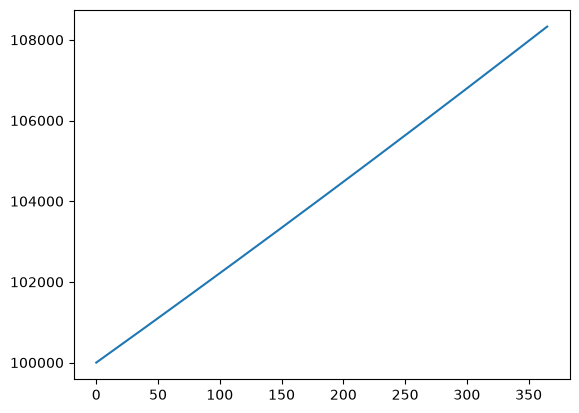

In [3]:
plt.plot(simulate_fd(100000, 0.08/365, 365))

## Simulate a Stock Market Index

In [4]:
INITIAL_STOCK_PRICE = 82408
N_DAYS = 365
RETURNS_MEAN = 0.03/100
RETURNS_STD = 0.7/100

In [5]:
def sample_stock_prices(amount: float, daily_returns_mean: float, daily_returns_std, n_days: int=365):
    daily_prices = [amount]
    
    for i in range(n_days):
        price_today = daily_prices[-1]
        returns_today = 1 + np.random.normal(loc=daily_returns_mean, scale=daily_returns_std)
        price_tomorrow = price_today * returns_today
        daily_prices.append(price_tomorrow)
    
    return daily_prices

In [6]:
prices = sample_stock_prices(100000, 0.00/100, 0.7/100)

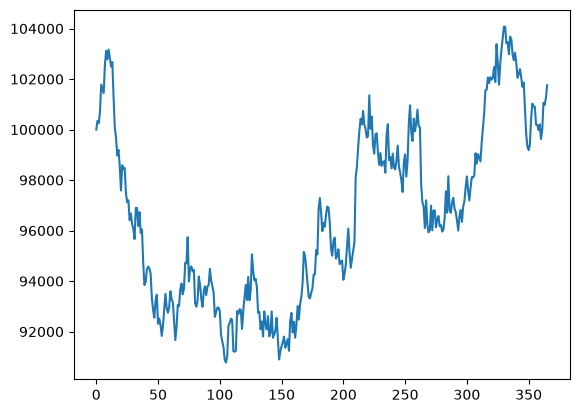

In [7]:
plt.plot(prices)

### FD vs Sensex

In [8]:
def plot_time_series(time_series1: list, time_series2: list):
    data = list(zip(time_series1, time_series2))
    columns = ['series1', 'series2']
    df = pd.DataFrame(data=data, columns=columns)
    df.plot.line()

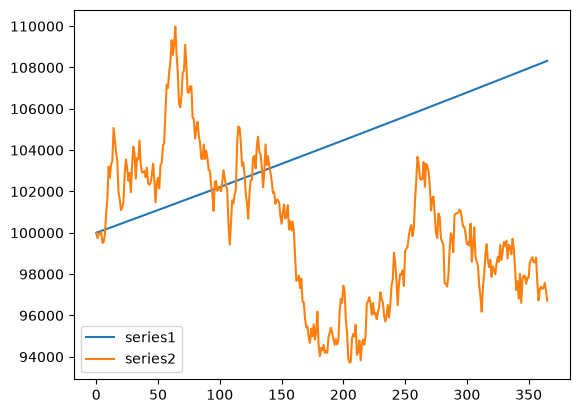

In [9]:
plot_time_series(
    simulate_fd(100000, 0.0219/100, 365),
    sample_stock_prices(100000, 0.02/100, 0.7/100)
)